# Preface

Telecom Churn Analysis

---

Steps we are going to follow in this project are outlined below-
1. Import Libraries
2. Load Data
3. Data Overview
4. Exploratory Data Analysis (EDA)
5. Data Preprocessing
6. Model Building
7. Model Evaluation
8. Insights & Conclusions


---


Dataset reference : https://www.kaggle.com/datasets/mnassrib/telecom-churn-datasets?resource=download

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
%matplotlib inline

# Load Data:

In [2]:
#df_train = pd.read_csv('https://drive.google.com/file/d/1bcpIE3XwQHxryLNRereeZ_kS5Jh35Db0/view?usp=drive_link')
#df_test = pd.read_csv('https://drive.google.com/file/d/1qthVPYkclEVJSjm4T8ZcVnQWbNIJr5jl/view?usp=drive_link')

df_train = pd.read_csv('/content/sample_data/churn-bigml-80.csv')
df_test = pd.read_csv('/content/sample_data/churn-bigml-20.csv')

print("Train Data Shape: ",df_train.shape)
print("Test Data Shape: ",df_test.shape)

Train Data Shape:  (2666, 20)
Test Data Shape:  (667, 20)


In [3]:
df_train.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
df_test.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


#  Data Types & Nulls:

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [7]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    object 
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    int64  
 3   International plan      667 non-null    object 
 4   Voice mail plan         667 non-null    object 
 5   Number vmail messages   667 non-null    int64  
 6   Total day minutes       667 non-null    float64
 7   Total day calls         667 non-null    int64  
 8   Total day charge        667 non-null    float64
 9   Total eve minutes       667 non-null    float64
 10  Total eve calls         667 non-null    int64  
 11  Total eve charge        667 non-null    float64
 12  Total night minutes     667 non-null    float64
 13  Total night calls       667 non-null    int64  
 14  Total night charge      667 non-null    fl

In [8]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Account length,2666.0,100.620405,39.563974,1.00,73.0000,100.00,127.000,243.00
Area code,2666.0,437.438860,42.521018,408.00,408.0000,415.00,510.000,510.00
Number vmail messages,2666.0,8.021755,13.612277,0.00,0.0000,0.00,19.000,50.00
Total day minutes,2666.0,179.481620,54.210350,0.00,143.4000,179.95,215.900,350.80
Total day calls,2666.0,100.310203,19.988162,0.00,87.0000,101.00,114.000,160.00
Total day charge,2666.0,30.512404,9.215733,0.00,24.3800,30.59,36.700,59.64
Total eve minutes,2666.0,200.386159,50.951515,0.00,165.3000,200.90,235.100,363.70
Total eve calls,2666.0,100.023631,20.161445,0.00,87.0000,100.00,114.000,170.00
Total eve charge,2666.0,17.033072,4.330864,0.00,14.0500,17.08,19.980,30.91
Total night minutes,2666.0,201.168942,50.780323,43.70,166.9250,201.15,236.475,395.00


In [9]:
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
Account length,667.0,102.841079,40.819480,1.00,76.00,102.00,128.000,232.00
Area code,667.0,436.157421,41.783305,408.00,408.00,415.00,415.000,510.00
Number vmail messages,667.0,8.407796,13.994480,0.00,0.00,0.00,20.000,51.00
Total day minutes,667.0,180.948126,55.508628,25.90,146.25,178.30,220.700,334.30
Total day calls,667.0,100.937031,20.396790,30.00,87.50,101.00,115.000,165.00
Total day charge,667.0,30.761769,9.436463,4.40,24.86,30.31,37.520,56.83
Total eve minutes,667.0,203.355322,49.719268,48.10,171.05,203.70,236.450,361.80
Total eve calls,667.0,100.476762,18.948262,37.00,88.00,101.00,113.000,168.00
Total eve charge,667.0,17.285262,4.226160,4.09,14.54,17.31,20.095,30.75
Total night minutes,667.0,199.685307,49.759931,23.20,167.95,201.60,231.500,367.70


# EDA

In [4]:
df_train['Churn'].value_counts()

,count
Churn,
False,2278
True,388


In [5]:
print(df_train['Churn'].value_counts())

Churn
False    2278
True      388
Name: count, dtype: int64


In [6]:
print("\nChurn %:")
print(df_train['Churn'].value_counts(normalize= True) * 100)


Churn %:
Churn
False    85.446362
True     14.553638
Name: proportion, dtype: float64


# Plotting and Visualization


Visualize Churn Distribution

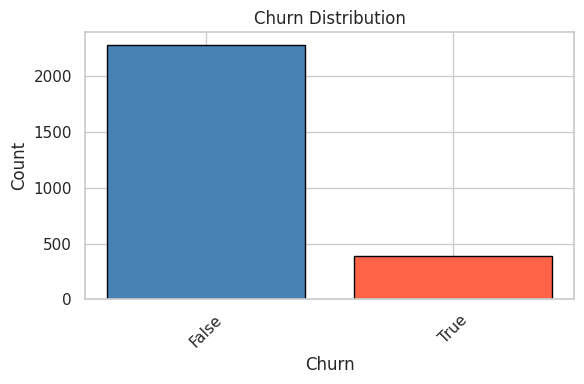

In [7]:
plt.figure(figsize=(6,4))
data = df_train['Churn'].value_counts()
labels = data.index.astype(str)
colors=['steelblue','tomato']
plt.bar(labels, data.values, color=colors, edgecolor='black')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Explore the 3 Categorical Columns

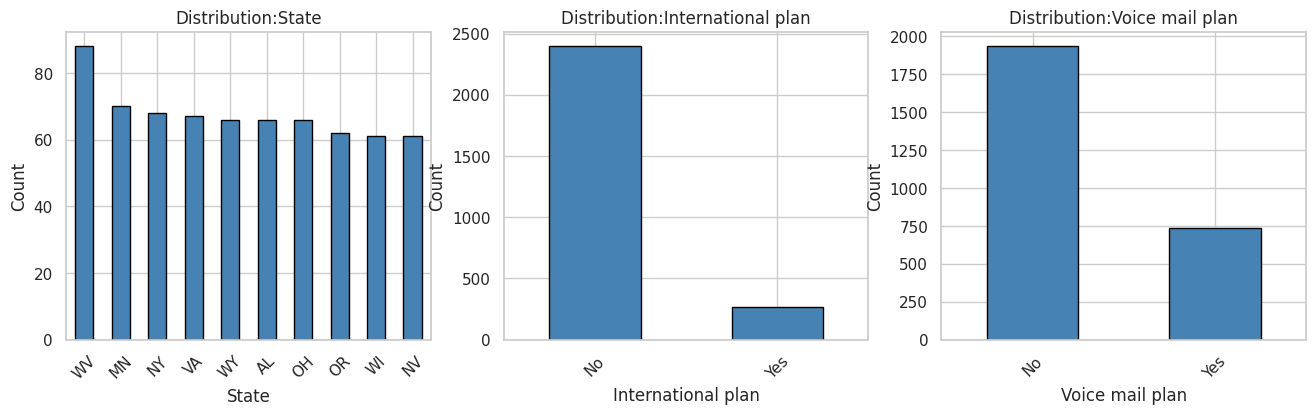

In [8]:
cat_cols = ['State','International plan','Voice mail plan']
fig,axes = plt.subplots(1,3, figsize=(16,4))

for i, col in enumerate(cat_cols):
  df_train[col].value_counts().head(10).plot(kind = 'bar', ax=axes[i], color='steelblue', edgecolor='black')
  axes[i].set_title(f'Distribution:{col}')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Count')
  axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout
plt.show()

Outlier Findings

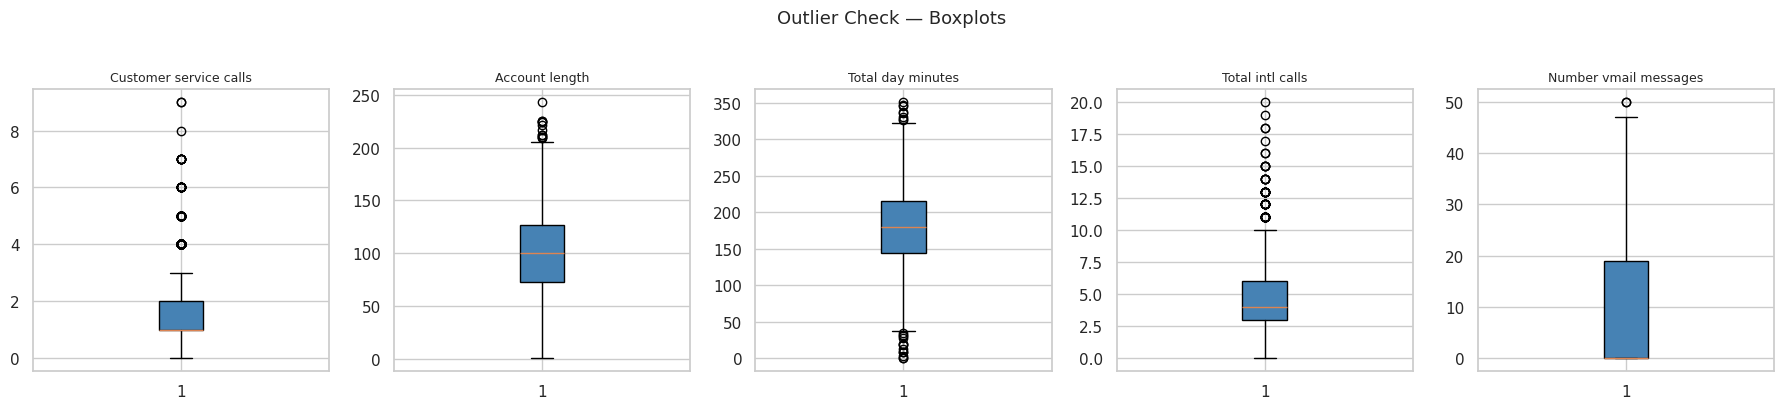

In [9]:
suspect_cols = ['Customer service calls', 'Account length',
                'Total day minutes', 'Total intl calls', 'Number vmail messages']
fig,axes = plt.subplots(1,len(suspect_cols), figsize=(18,4))

for i,col in enumerate(suspect_cols):
  axes[i].boxplot(df_train[col], patch_artist=True, boxprops=dict(facecolor='steelblue', color='black'))
  axes[i].set_title(col,fontsize=9)
  axes[i].set_xlabel('')
plt.suptitle('Outlier Check — Boxplots', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Corelation between the data

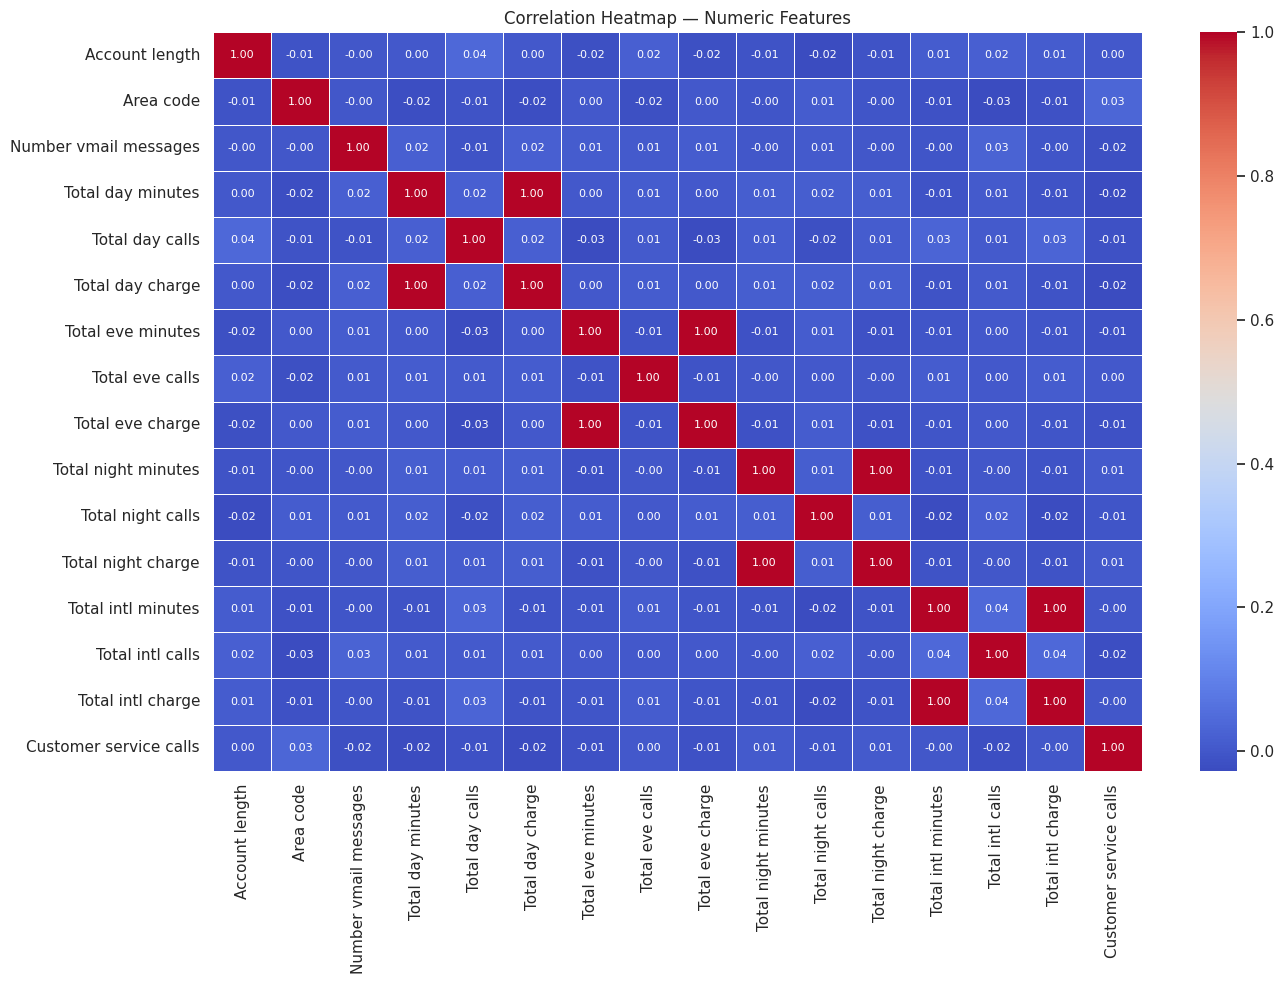

In [10]:
plt.figure(figsize=(14,10))
numeric_df = df_train.select_dtypes(include=['int64','float64'])

corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, annot_kws={"size":8})
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

# Bi-Variate Analysis

Churn vs Customer Service Calls

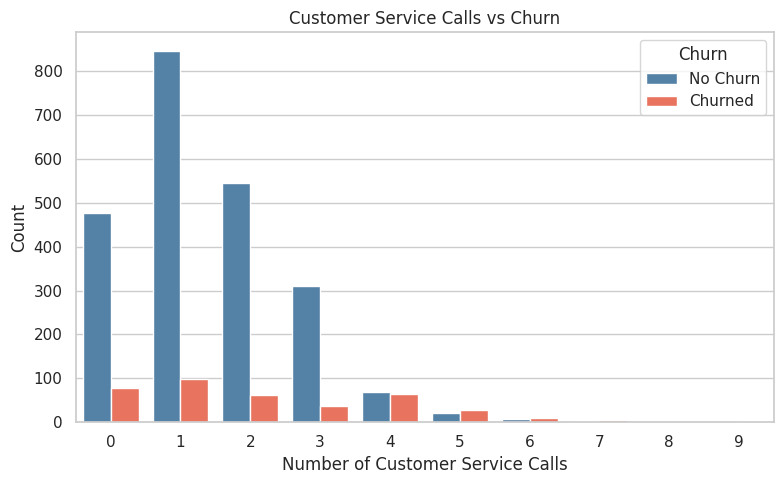

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_train, x = 'Customer service calls', hue='Churn', palette={False:'steelblue', True:'tomato'})
plt.title('Customer Service Calls vs Churn')
plt.xlabel('Number of Customer Service Calls')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['No Churn', 'Churned'])
plt.tight_layout()
plt.show()

Churn vs International Plan

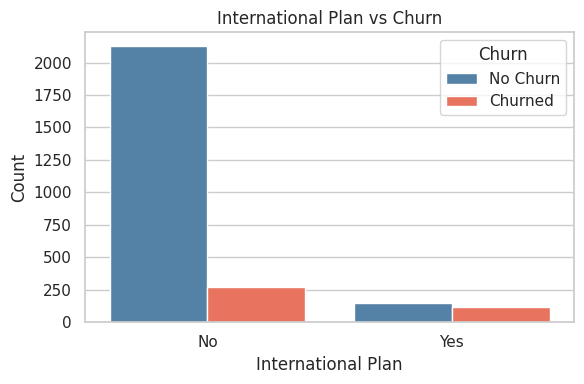

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_train, x='International plan',hue='Churn',palette={False:'steelblue', True:'tomato'})
plt.title('International Plan vs Churn')
plt.xlabel('International Plan')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['No Churn', 'Churned'])
plt.tight_layout()
plt.show()

Churn vs Voice Mail Plan

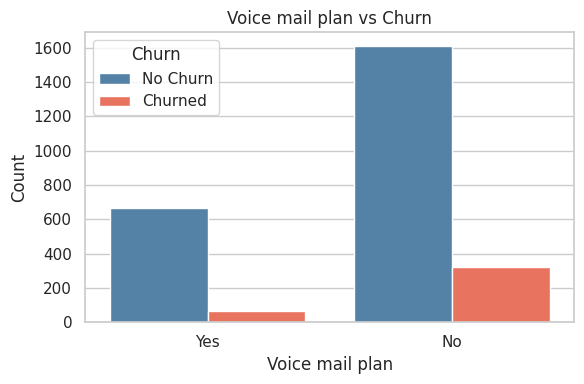

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_train, x='Voice mail plan', hue='Churn',palette={False:'steelblue', True:'tomato'})

plt.title('Voice mail plan vs Churn')
plt.xlabel('Voice mail plan')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['No Churn', 'Churned'])
plt.tight_layout()
plt.show()


 Churn vs Usage Minutes

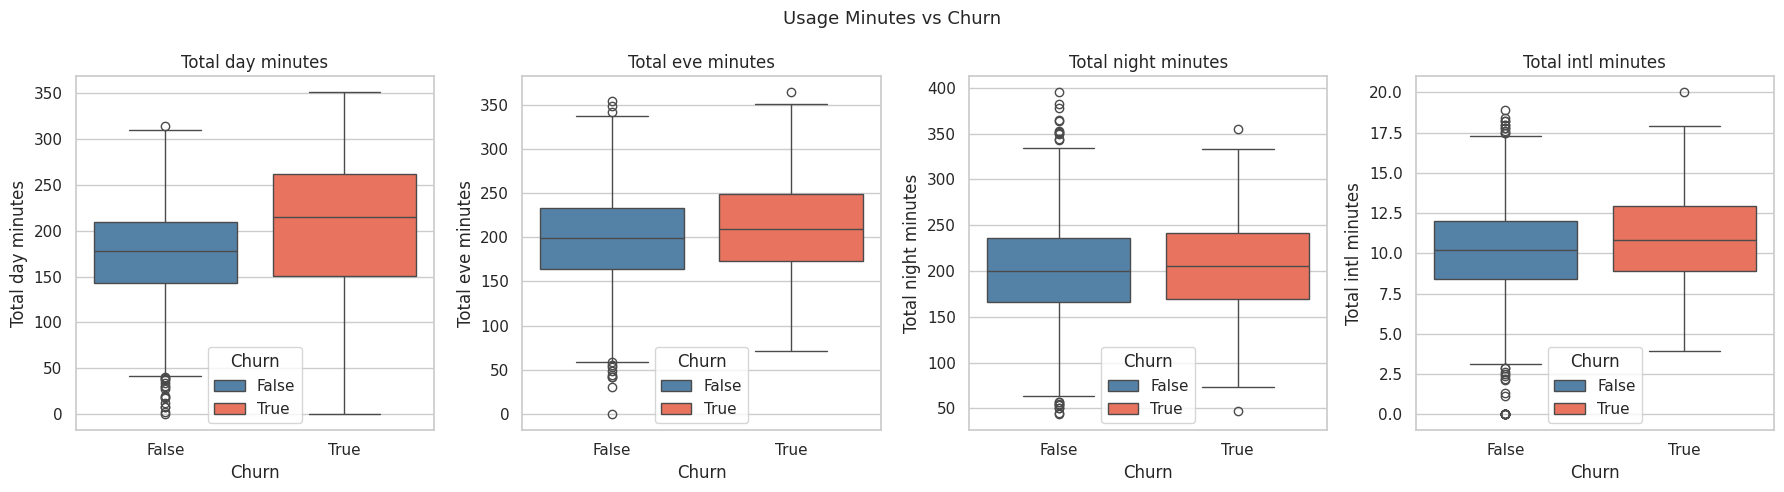

In [14]:
usage_cols = ['Total day minutes', 'Total eve minutes','Total night minutes', 'Total intl minutes']
fig,axes = plt.subplots(1,4, figsize=(18,5))

for i,col in enumerate(usage_cols):
  sns.boxplot(data=df_train, x='Churn', y=col, hue='Churn', palette={False:'steelblue', True:'tomato'}, ax=axes[i])
  axes[i].set_title(col)
  axes[i].set_xlabel('Churn')
plt.suptitle('Usage Minutes vs Churn', fontsize=13)
plt.tight_layout()
plt.show()

Overall Churn Rate by International Plan

In [15]:
churn_by_intl = (df_train.groupby('International plan')['Churn'].mean()*100).round(2)
churn_by_intl

,Churn
International plan,
No,11.27
Yes,43.70


# EDA Analysis

EDA Insight:
1. Customer Service Calls > 4 = High Churn Risk
This is the single strongest churn signal. A customer who calls support 5+ times is clearly frustrated. The business insight:

"Flag customers with 4+ service calls for immediate proactive retention outreach."

2. International Plan Customers Churn More
These customers likely find the international rates too expensive. Insight:

"International plan pricing may be uncompetitive - review and offer targeted discounts."

3. Voicemail Plan Reduces Churn
Customers with voicemail are more engaged and embedded in the service - harder to leave. Insight:

"Promote voicemail plan adoption as a retention strategy."

4. Total Day Minutes Drives Churn
Heavy daytime users who churn are likely high-value customers leaving for a competitor with better day rates. Insight:

"High day-usage customers need priority retention offers."

# Data Pre-processing

This is where we prepare the data for ML models. Here's exactly what we need to do and why:

Task: Drop charge columns

What: Remove charge-related columns from the dataset
Why: These columns are highly correlated (multicollinear) with the corresponding minutes columns, which can confuse models and reduce performance

Task: Encode object columns

What: Convert categorical/string (object) columns into numerical representations (e.g., label encoding or one-hot encoding)
Why: Machine learning models require numerical input and cannot process raw text data

Task: Encode boolean (Churn)

What: Convert True/False values into 1/0
Why: Numerical representation makes it usable for model training and ensures consistency in data format

Task: Feature scaling

What: Scale numerical features (e.g., using standardization or normalization)
Why: Prevents features with larger values from dominating the model and improves convergence and performance

Drop the columns

In [3]:
cols_to_drop = ['Total day charge', 'Total eve charge','Total night charge', 'Total intl charge']

df_train = df_train.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)

print("Train shape after dropping:", df_train.shape)
print("Test shape after dropping:", df_test.shape)

Train shape after dropping: (2666, 16)
Test shape after dropping: (667, 16)


Encode Categorical Columns

In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cat_cols = ['International plan','Voice mail plan']
for col in cat_cols:
  df_train[col] = le.fit_transform(df_train[col])
  df_test[col] = le.transform(df_test[col])

# Drop State — too many unique values, low predictive value for now
df_train = df_train.drop(columns='State')
df_test = df_test.drop(columns = 'State')

print("Encoding Done............")
df_train.head()

Encoding Done............


,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn
0,128,415,0,1,25,265.1,110,197.4,99,244.7,91,10.0,3,1,False
1,107,415,0,1,26,161.6,123,195.5,103,254.4,103,13.7,3,1,False
2,137,415,0,0,0,243.4,114,121.2,110,162.6,104,12.2,5,0,False
3,84,408,1,0,0,299.4,71,61.9,88,196.9,89,6.6,7,2,False
4,75,415,1,0,0,166.7,113,148.3,122,186.9,121,10.1,3,3,False


Encode Target VAriable

In [5]:
df_train['Churn'] = df_train['Churn'].astype(int)
df_test['Churn'] = df_test['Churn'].astype(int)

print("Churn value counts after encoding:")
print(df_train['Churn'].value_counts())

Churn value counts after encoding:
Churn
0    2278
1     388
Name: count, dtype: int64


Separate Features and Target

In [6]:
X_train = df_train.drop(columns=['Churn'])
y_train = df_train['Churn']

X_test = df_test.drop(columns=['Churn'])
y_test   = df_test['Churn']

print("X_train shape: ",X_train.shape)
print("X_test shape: ",X_test.shape)
print("y_train distribution:\n", y_train.value_counts())

X_train shape:  (2666, 14)
X_test shape:  (667, 14)
y_train distribution:
 Churn
0    2278
1     388
Name: count, dtype: int64


Feature Scaling

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled  = scaler.fit_transform(X_test)

print("Sclaning Completed.......")
print("Sample Scale Values:", X_train_scaled[0][:5])

Sclaning Completed.......
Sample Scale Values: [ 0.69216332 -0.52781119 -0.33569005  1.62391742  1.24750838]


# Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled,y_train)

print("Logistic Regression Trained Successfully")

Logistic Regression Trained Successfully


# Predictions

In [9]:
y_pred_lr = lr_model.predict(X_test_scaled)
print("Sample Predictions: ", y_pred_lr[:10])
print("Actual Values...........: ", y_test.values[:10])

Sample Predictions:  [0 0 1 0 0 0 0 0 0 0]
Actual Values...........:  [0 1 1 0 0 0 0 1 0 0]


# Evaluation

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("=" * 50)
print("LOGISTIC REGRESSION - MODEL EVALUATION")
print("=" * 50)

print("\nClassification Report: ")
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churned']))
print("\nROC-AUC Score : ", roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:,1]).round(4))

LOGISTIC REGRESSION - MODEL EVALUATION

Classification Report: 
              precision    recall  f1-score   support

    No Churn       0.88      0.96      0.92       572
     Churned       0.44      0.18      0.25        95

    accuracy                           0.85       667
   macro avg       0.66      0.57      0.59       667
weighted avg       0.81      0.85      0.82       667


ROC-AUC Score :  0.8253


# Confusion Matrix

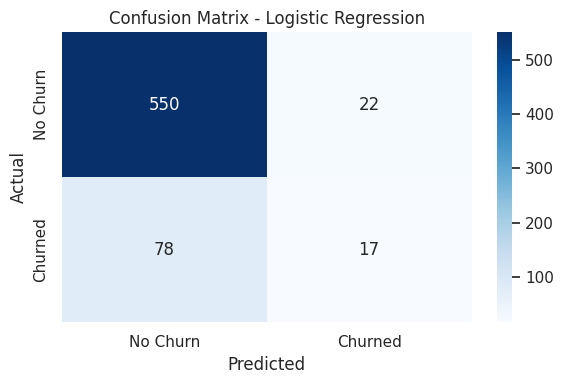

In [11]:
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn','Churned'], yticklabels=['No Churn','Churned'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

78 out of 95 churners were completely missed. The model only caught 17. That's why Recall is just 17.9% - dangerously low for a churn use case.
Recall for the churned class is our north star metric in this project.
ROC-AUC = 0.82
This is actually a good sign. It means the model has learned something real - it can rank churners above non-churners reasonably well. The problem is the decision threshold and class imbalance, not the model's intelligence.

We'll now do two things here:
Fix 1 → Address class imbalance using class_weight='balanced'
Fix 2 → Move to Random Forest - a much more powerful model for this type of data

# Logistic Regression with Balanced Class Weight

In [12]:
lr_balanced = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

lr_balanced.fit(X_train_scaled, y_train)

y_pred_lr_balanced = lr_balanced.predict(X_test_scaled)

print("=" * 50)
print("LOGISTIC REGRESSION - BALANCED WEIGHT")
print("=" * 50)

print(classification_report(y_test, y_pred_lr_balanced, target_names=['No Churn','Churned']))
print("ROC-AUC : ", roc_auc_score(y_test, lr_balanced.predict_proba(X_test_scaled)[:,1].round(4)))


LOGISTIC REGRESSION - BALANCED WEIGHT
              precision    recall  f1-score   support

    No Churn       0.95      0.78      0.85       572
     Churned       0.36      0.76      0.49        95

    accuracy                           0.77       667
   macro avg       0.66      0.77      0.67       667
weighted avg       0.87      0.77      0.80       667

ROC-AUC :  0.8288553551711446


# Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print("=" * 50)
print("RANDOM FOREST — MODEL EVALUATION")
print("=" * 50)

print(classification_report(y_test, y_pred_rf, target_names=['No Churn','Churn']))
print("ROC-AUC : ", roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:,1]).round(4))

RANDOM FOREST — MODEL EVALUATION
              precision    recall  f1-score   support

    No Churn       0.94      1.00      0.97       572
       Churn       0.98      0.59      0.74        95

    accuracy                           0.94       667
   macro avg       0.96      0.79      0.85       667
weighted avg       0.94      0.94      0.93       667

ROC-AUC :  0.9203


# Compare all Models side by side

In [14]:
from sklearn.metrics import f1_score, recall_score

models = {
    'LR Baseline'  : y_pred_lr,
    'LR Balanced'  : y_pred_lr_balanced,
    'Random Forest': y_pred_rf
    }

print(f"{'Model':<20} {'Recall':>8} {'F1':>8} {'ROC-AUC':>10}")
print("=" * 50)

for name,preds in models.items():
  if name == 'LR Baseline':
    proba = lr_model.predict_proba(X_test_scaled)[:,1]
  elif name == 'LR Balanced':
    proba = lr_balanced.predict_proba(X_test_scaled)[:,1]
  else:
    proba = rf_model.predict_proba(X_test_scaled)[:,1]

  recall = round(recall_score(y_test, preds), 4)
  f1 = round(f1_score(y_test, preds), 4)
  roc_auc = round(roc_auc_score(y_test, proba), 4)
  print(f"{name:<20} {recall:>8} {f1:>8} {roc_auc:>10}")

Model                  Recall       F1    ROC-AUC
LR Baseline            0.1789   0.2537     0.8253
LR Balanced            0.7579   0.4881     0.8288
Random Forest          0.5895   0.7368     0.9203


Feature Importance- Random Forest

/tmp/ipykernel_11693/3266584698.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= feat_df, x='Importance', y='Feature', palette='coolwarm')


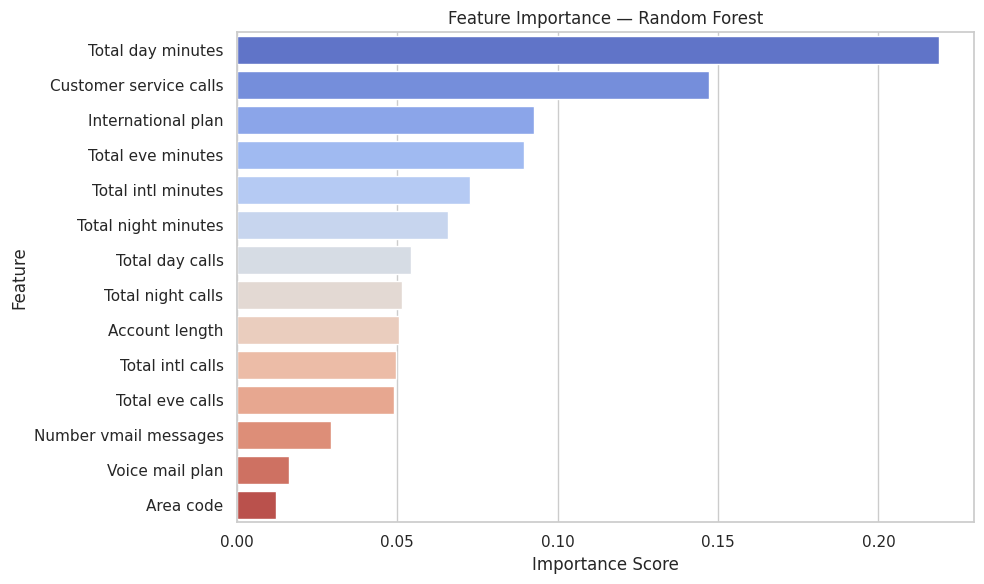

               Feature  Importance
     Total day minutes    0.218849
Customer service calls    0.147320
    International plan    0.092601
     Total eve minutes    0.089561
    Total intl minutes    0.072733
   Total night minutes    0.065854
       Total day calls    0.054340
     Total night calls    0.051642
        Account length    0.050701
      Total intl calls    0.049691
       Total eve calls    0.048973
 Number vmail messages    0.029447
       Voice mail plan    0.016140
             Area code    0.012148


In [25]:
feature_names  = X_train.columns
importances = rf_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances
}).sort_values('Importance', ascending = False)

plt.figure(figsize=(10,6))
sns.barplot(data= feat_df, x='Importance', y='Feature', palette='coolwarm')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(feat_df.to_string(index=False))

# XGBoost

In [29]:
!pip install xgboost -q

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100, random_state=42,
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
    eval_metric='logloss', verbosity=0
)

xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("=" * 50)
print("XGBOOST - MODEL EVALUATION")
print("=" * 50)

print(classification_report(
    y_test, y_pred_xgb,
    target_names=['No Churn','Churned']
))
print("ROC-AUC: ",round(roc_auc_score(
    y_test, xgb_model.predict_proba(X_test_scaled)[:,1]), 4
))

XGBOOST - MODEL EVALUATION
              precision    recall  f1-score   support

    No Churn       0.95      0.95      0.95       572
     Churned       0.70      0.67      0.68        95

    accuracy                           0.91       667
   macro avg       0.82      0.81      0.82       667
weighted avg       0.91      0.91      0.91       667

ROC-AUC:  0.8522


# Comapre all models now

In [31]:
all_models = {
    'LR Baseline'  : (y_pred_lr, lr_model),
    'LR Balanced'  : (y_pred_lr_balanced, lr_balanced),
    'Random Forest': (y_pred_rf, rf_model),
    'XGBoost'      : (y_pred_xgb, xgb_model)
}


print(f"{'Model':<20} {'Recall':>8} {'F1':>8} {'ROC-AUC':>10}")
print("-" * 50)

for name, (preds,model) in all_models.items():
  proba = model.predict_proba(X_test_scaled)[:,1]
  recall = round(recall_score(y_test,preds), 4)
  f1 = round(f1_score(y_test, preds), 4)
  roc_auc = round(roc_auc_score(y_test, proba), 4)
  print(f"{name:<20} {recall:>8} {f1:>8} {roc_auc:>10}")

Model                  Recall       F1    ROC-AUC
--------------------------------------------------
LR Baseline            0.1789   0.2537     0.8253
LR Balanced            0.7579   0.4881     0.8288
Random Forest          0.5895   0.7368     0.9203
XGBoost                0.6737   0.6845     0.8522


In [1]:
print("""
╔══════════════════════════════════════════════════════════╗
║           TELECOM CHURN ANALYSIS — FINAL SUMMARY        ║
╠══════════════════════════════════════════════════════════╣
║  Dataset    : Orange Telecom (2666 train / 667 test)     ║
║  Problem    : Binary Classification (Churn vs No Churn)  ║
║  Churn Rate : ~14% (Class Imbalanced)                    ║
╠══════════════════════════════════════════════════════════╣
║  BEST MODEL : Random Forest (class_weight=balanced)      ║
║  Recall     : 0.590                                      ║
║  F1 Score   : 0.737                                      ║
║  ROC-AUC    : 0.920                                      ║
╠══════════════════════════════════════════════════════════╣
║  TOP CHURN DRIVERS (Feature Importance)                  ║
║  1. Total Day Minutes                                     ║
║  2. Customer Service Calls                                ║
║  3. International Plan                                    ║
╠══════════════════════════════════════════════════════════╣
║  KEY BUSINESS INSIGHTS                                   ║
║  • Flag customers with 4+ service calls immediately      ║
║  • Review international plan pricing urgently            ║
║  • Promote voicemail plan as retention strategy          ║
║  • Monitor high day-usage customers proactively          ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║           TELECOM CHURN ANALYSIS — FINAL SUMMARY        ║
╠══════════════════════════════════════════════════════════╣
║  Dataset    : Orange Telecom (2666 train / 667 test)     ║
║  Problem    : Binary Classification (Churn vs No Churn)  ║
║  Churn Rate : ~14% (Class Imbalanced)                    ║
╠══════════════════════════════════════════════════════════╣
║  BEST MODEL : Random Forest (class_weight=balanced)      ║
║  Recall     : 0.590                                      ║
║  F1 Score   : 0.737                                      ║
║  ROC-AUC    : 0.920                                      ║
╠══════════════════════════════════════════════════════════╣
║  TOP CHURN DRIVERS (Feature Importance)                  ║
║  1. Total Day Minutes                                     ║
║  2. Customer Service Calls                                ║
║  3. International Plan                                    ║
╠════════════════════